<a href="https://colab.research.google.com/github/guthasushmasree/ML-LabPrograms/blob/main/ml(skill_15).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload 'placement_predict_50k Dataset.csv'


Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset.csv

Dataset Loaded Successfully!
Dataset Shape: (50000, 32)

First 5 Rows:
   StudentID  Gender       City CollegeTier Stream Specialisation Hostel  \
0          1    Male  Ahmedabad       Tier2    ECE     Networking     No   
1          2  Female     Mumbai       Tier2    ECE    DataScience    Yes   
2          3    Male    Kolkata       Tier2     IT    DataScience    Yes   
3          4    Male     Jaipur       Tier1     CS             AI     No   
4          5    Male       Pune       Tier2     IT    DataScience    Yes   

  HistoryOfBacklogs  SGPA_Sem1  SGPA_Sem2  ...  Publications  \
0                No       6.02       6.54  ...             0   
1               Yes       5.84       5.12  ...             0   
2                No       4.91       5.29  ...             0   
3                No       7.67       8.03  ...             0   
4                No       8.14       8.97  ...             1   

   Aptit

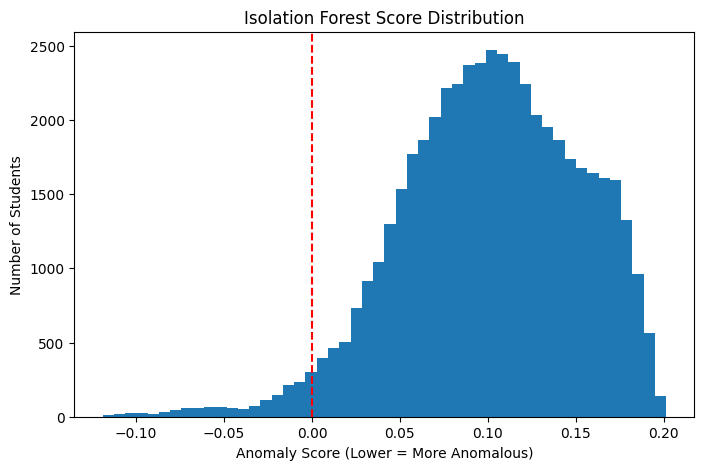


CONTAMINATION SWEEP
contamination=0.01 | flagged=501  | fakes caught=10/10
contamination=0.03 | flagged=1501 | fakes caught=10/10
contamination=0.05 | flagged=2501 | fakes caught=10/10
contamination=0.1  | flagged=5001 | fakes caught=10/10


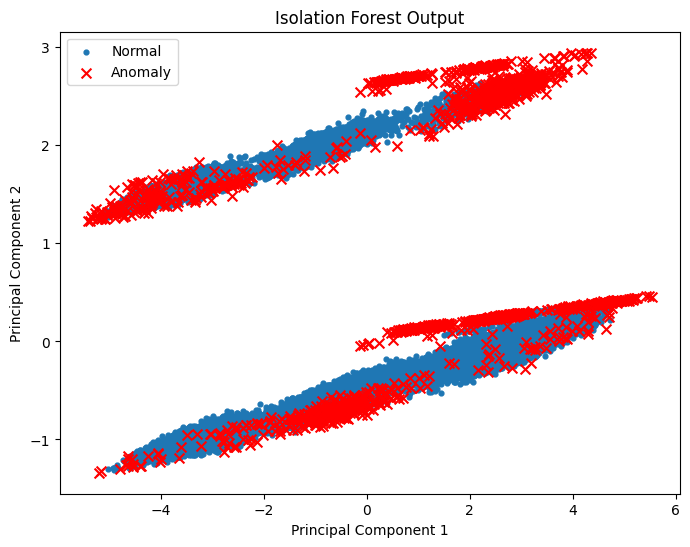


FEATURE COMPARISON
                    Anomalies  Normal
CGPA                     7.57    7.24
AttendancePercent       70.56   76.89
HistoryOfBacklogs        0.47    0.17
Internships              2.13    1.10
Projects                 3.56    2.06
Certifications           2.22    1.92
CodingTestScore         61.42   57.29
SoftSkillsRating         3.32    3.15
MockInterviewScore      59.33   55.21

First 10 Detected Anomalies
     CGPA  AttendancePercent  HistoryOfBacklogs  Internships  Projects  \
43   6.84          69.900000                1.0          0.0       0.0   
117  9.84          93.900000                1.0          3.0       4.0   
123  9.98          97.300000                0.0          3.0       5.0   
143  9.75          73.200000                0.0          3.0       5.0   
184  4.05          52.660174                0.0          2.0       2.0   
191  9.79          63.200000                0.0          3.0       5.0   
196  4.00          74.400000                1.0      

In [ ]:
# ==========================================
# Placement Dataset Anomaly Detection
# Isolation Forest + PCA
# Dataset: placement_predict_50k Dataset.csv
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

# ------------------------------------------
# STEP 1: Upload Dataset
# ------------------------------------------
print("Upload 'placement_predict_50k Dataset.csv'")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("\nDataset Loaded Successfully!")
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

# ------------------------------------------
# STEP 2: Convert Backlogs (Yes/No -> 1/0)
# ------------------------------------------
df["HistoryOfBacklogs"] = df["HistoryOfBacklogs"].map({
    "No": 0,
    "Yes": 1
})

# ------------------------------------------
# STEP 3: Select Correct Features
# ------------------------------------------
F = [
    "CGPA",
    "AttendancePercent",
    "HistoryOfBacklogs",
    "Internships",
    "Projects",
    "Certifications",
    "CodingTestScore",
    "SoftSkillsRating",
    "MockInterviewScore"
]

print("\nFeatures Used:", F)

# ------------------------------------------
# STEP 4: Create 10 Fake Anomaly Students
# ------------------------------------------
rng = np.random.default_rng(0)

fake = pd.DataFrame({
    "CGPA": rng.uniform(9.5, 10, 10),
    "AttendancePercent": rng.uniform(45, 55, 10),
    "HistoryOfBacklogs": np.ones(10),
    "Internships": np.zeros(10),
    "Projects": np.zeros(10),
    "Certifications": np.zeros(10),
    "CodingTestScore": rng.uniform(0, 15, 10),
    "SoftSkillsRating": rng.uniform(1, 2, 10),
    "MockInterviewScore": rng.uniform(10, 30, 10)
})

# ------------------------------------------
# STEP 5: Combine Real + Fake Data
# ------------------------------------------
data = pd.concat([df[F], fake], ignore_index=True)

# Ground truth for injected fake records
is_fake = np.r_[np.zeros(len(df)), np.ones(10)].astype(bool)

# ------------------------------------------
# STEP 6: Handle Missing Values
# ------------------------------------------
imputer = SimpleImputer(strategy="median")
data = pd.DataFrame(
    imputer.fit_transform(data),
    columns=data.columns
)

print("\nRemaining NaN values:", data.isna().sum().sum())

# ------------------------------------------
# STEP 7: Standardize Features
# ------------------------------------------
scaler = StandardScaler()
X = scaler.fit_transform(data)

# ------------------------------------------
# STEP 8: Train Isolation Forest
# ------------------------------------------
iso = IsolationForest(
    contamination=0.03,
    n_estimators=300,
    random_state=0
)

iso.fit(X)

flag = iso.predict(X)
score = iso.decision_function(X)

print("\n==============================")
print("INITIAL RESULTS")
print("==============================")
print("Flagged:", int((flag == -1).sum()), "rows")
print("Of the 10 injected fakes detected:",
      int((flag[is_fake] == -1).sum()), "/10")

# ------------------------------------------
# STEP 9: Score Histogram
# ------------------------------------------
plt.figure(figsize=(8,5))
plt.hist(score, bins=50)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Anomaly Score (Lower = More Anomalous)")
plt.ylabel("Number of Students")
plt.title("Isolation Forest Score Distribution")
plt.show()

# ------------------------------------------
# STEP 10: Contamination Sweep
# ------------------------------------------
print("\n==============================")
print("CONTAMINATION SWEEP")
print("==============================")

for c in [0.01, 0.03, 0.05, 0.10]:

    f = IsolationForest(
        contamination=c,
        n_estimators=300,
        random_state=0
    ).fit_predict(X)

    print(
        f"contamination={c:<4} | "
        f"flagged={int((f==-1).sum()):<4} | "
        f"fakes caught={int((f[is_fake]==-1).sum())}/10"
    )

# ------------------------------------------
# STEP 11: PCA Visualization
# ------------------------------------------
pca = PCA(n_components=2, random_state=0)
X2 = pca.fit_transform(X)

plt.figure(figsize=(8,6))

plt.scatter(
    X2[flag == 1,0],
    X2[flag == 1,1],
    s=12,
    label="Normal"
)

plt.scatter(
    X2[flag == -1,0],
    X2[flag == -1,1],
    c="red",
    marker="x",
    s=50,
    label="Anomaly"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Isolation Forest Output")
plt.legend()
plt.show()

# ------------------------------------------
# STEP 12: Compare Anomalies vs Normal
# ------------------------------------------
print("\n==============================")
print("FEATURE COMPARISON")
print("==============================")

comparison = pd.DataFrame({
    "Anomalies": data[flag == -1].mean(),
    "Normal": data[flag == 1].mean()
}).round(2)

print(comparison)

# ------------------------------------------
# STEP 13: Show First 10 Detected Anomalies
# ------------------------------------------
print("\nFirst 10 Detected Anomalies")

anomalies = data[flag == -1].copy()
print(anomalies.head(10))

# ------------------------------------------
# STEP 14: Compare with Dataset's IsAnomaly
# ------------------------------------------
if "IsAnomaly" in df.columns:

    predicted = np.zeros(len(df), dtype=int)
    predicted[np.where(flag[:len(df)] == -1)[0]] = 1

    matches = (predicted == df["IsAnomaly"]).sum()

    print("\n==============================")
    print("COMPARISON WITH DATASET LABELS")
    print("==============================")
    print(f"Matching rows: {matches}/{len(df)}")
    print(f"Accuracy: {matches/len(df)*100:.2f}%")